In [1]:
# if the current working directory is src, change it to the parent directory
import os
if os.getcwd().endswith('experimental'):
    os.chdir('../..')

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
from scipy.integrate import quad
from soil_diskin.continuum_models import PowerLawDisKin
from soil_diskin.constants import LAMBDA_14C
from tqdm import tqdm

### Read results of powerlaw and lognormal fits

In [ ]:
# load data
ln = pd.read_csv('results/03_calibrate_models/03b_lognormal_predictions_calcurve.csv')

# convert lognromal parameters to mean and std
ln['sigma'] = np.sqrt(np.log(ln['pred'] / ln['turnover']))
ln['mu'] = -np.log(np.sqrt(ln['turnover']**3 / ln['pred']))

from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterSciNotation
fig, ax = plt.subplots(dpi=300)

# make the colorbar with log scale
scatter = ax.scatter(ln['mu'], ln['sigma'], c=ln['pred'], cmap='viridis', norm=LogNorm())
ax.set(xlabel='$\mu$', ylabel='$\sigma$', title='$\mu$ vs $\sigma$ for log-normal model')
cbar = plt.colorbar(scatter, label='A')
# add more numbers to the colorbar ticks (1, 2, 5 per decade)
cbar.ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0, 2.0, 5.0)))
cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation())
cbar.minorticks_off()

A_vals = np.logspace(3, 5, num=4)
mus = np.stack([np.linspace(-3, 4, num=100)] * 4, axis=1).T
sigmas = np.sqrt(2 * (mus + np.log(A_vals[:, None])) / 3)

# color each fixed-A curve with the same colormap/normalization as the scatter,
# so the line colors correspond to the colorbar
for i, A in enumerate(A_vals):
    ax.plot(mus[i, :], sigmas[i, :], color=scatter.cmap(scatter.norm(A)))

# add a line that looks normal to the fixed-A curves.
# the curves satisfy sigma^2 = 2*(mu + log(A))/3, so along a curve the tangent
# slope (in data coords) is dsigma/dmu = 1/(3*sigma).
mu0 = np.nanmedian(ln['mu'])
sigma0 = np.nanmedian(ln['sigma'])
tangent_slope = 1.0 / (3 * sigma0)

# the x and y axes have different scales, so a line that is perpendicular in *data*
# coords does not look perpendicular on screen. compute the perpendicular in *display*
# coords (where it looks right) and convert the resulting slope back to data coords.
fig.canvas.draw()  # finalize the data<->display transform
trans = ax.transData
p0 = trans.transform((mu0, sigma0))
p1 = trans.transform((mu0 + 1, sigma0 + tangent_slope))
tangent_disp = p1 - p0
normal_disp = np.array([-tangent_disp[1], tangent_disp[0]])  # rotate 90 deg in display space
inv = trans.inverted()
d = inv.transform(p0 + normal_disp) - inv.transform(p0)  # normal direction in data coords
normal_slope = d[1] / d[0]

# span the normal line over the range of A actually present in the scatter data.
# substituting the curve mu = 3*sigma^2/2 - log(A) into the normal line
# sigma = sigma0 + m*(mu - mu0) gives a quadratic in sigma:
#   (3/2)*sigma^2 - (1/m)*sigma + (sigma0/m - mu0 - log(A)) = 0
def normal_curve_intersection(A, m, mu0, sigma0):
    roots = np.roots([1.5, -1.0 / m, sigma0 / m - mu0 - np.log(A)])
    roots = roots[np.isreal(roots)].real
    roots = roots[roots > 0]
    sigma_int = roots[np.argmin(np.abs(roots - sigma0))]
    mu_int = mu0 + (sigma_int - sigma0) / m
    return mu_int, sigma_int

A_lo, A_hi = ln['pred'].min(), ln['pred'].max()
log_A_range = np.log(A_hi) - np.log(A_lo)  # width of the line in log(A) units
endpoints = np.array([
    normal_curve_intersection(A_lo, normal_slope, mu0, sigma0),
    normal_curve_intersection(A_hi, normal_slope, mu0, sigma0),
])
ax.plot(endpoints[:, 0], endpoints[:, 1], 'k--', label='normal')

# label the line with its width, expressed as the log(A) range of the scatter data,
# placed alongside the line and rotated to match its on-screen angle
e0, e1 = trans.transform(endpoints[0]), trans.transform(endpoints[1])
angle = np.degrees(np.arctan2(e1[1] - e0[1], e1[0] - e0[0]))
if angle > 90:
    angle -= 180
elif angle < -90:
    angle += 180
mid_disp = (e0 + e1) / 2
offset = tangent_disp / np.linalg.norm(tangent_disp) * 14  # nudge to the side of the line
label_xy = inv.transform(mid_disp + offset)
ax.text(label_xy[0], label_xy[1], f'$\\Delta\\ln A$ = {log_A_range:.1f}',
        rotation=angle, rotation_mode='anchor', ha='center', va='center')

# annotate the uppermost (largest-A) fixed-A curve with the relationship formula,
# placing the text in the top-left white space with an arrow pointing at the curve
i_ann, k_ann = len(A_vals) - 1, 20  # uppermost curve, point to aim the arrow at
ax.annotate(r'$\sigma = \sqrt{2\mu + \frac{\log(A)}{3}}$',
            xy=(mus[i_ann, k_ann], sigmas[i_ann, k_ann]), xycoords='data',
            xytext=(0.04, 0.94), textcoords='axes fraction', ha='left', va='top',
            arrowprops=dict(arrowstyle='->', color='k'))

ax.set(xlabel='$\mu$', ylabel='$\sigma$', title='$\mu$ vs $\sigma$ for log-normal model with fixed A')

# Expected relations of mu, sigma and A
In the panel below, I show that the pattern we find above is expected. This is because, for a lognormal model in steady-state, 

$T = \exp(-\mu + \frac{\sigma^2}{2})$ and $A = T \exp(\sigma^2)$

As a result of these relationships, we get 

$\sigma^2 = \ln(A) - \ln(T)$ and $\mu = \frac{\sigma^2}{2} - \ln(T)$

Combining these gives 

$\mu = \frac{3\sigma^2}{2} - \ln(A)$

So for fixed A we expect a positive correlation of $\mu$ and $\sigma^2$ with a slope of $3/2$. We can check that this is what we get from IsRaD by binning the samples according to A. This would be a nice sanity check of our fitting.  


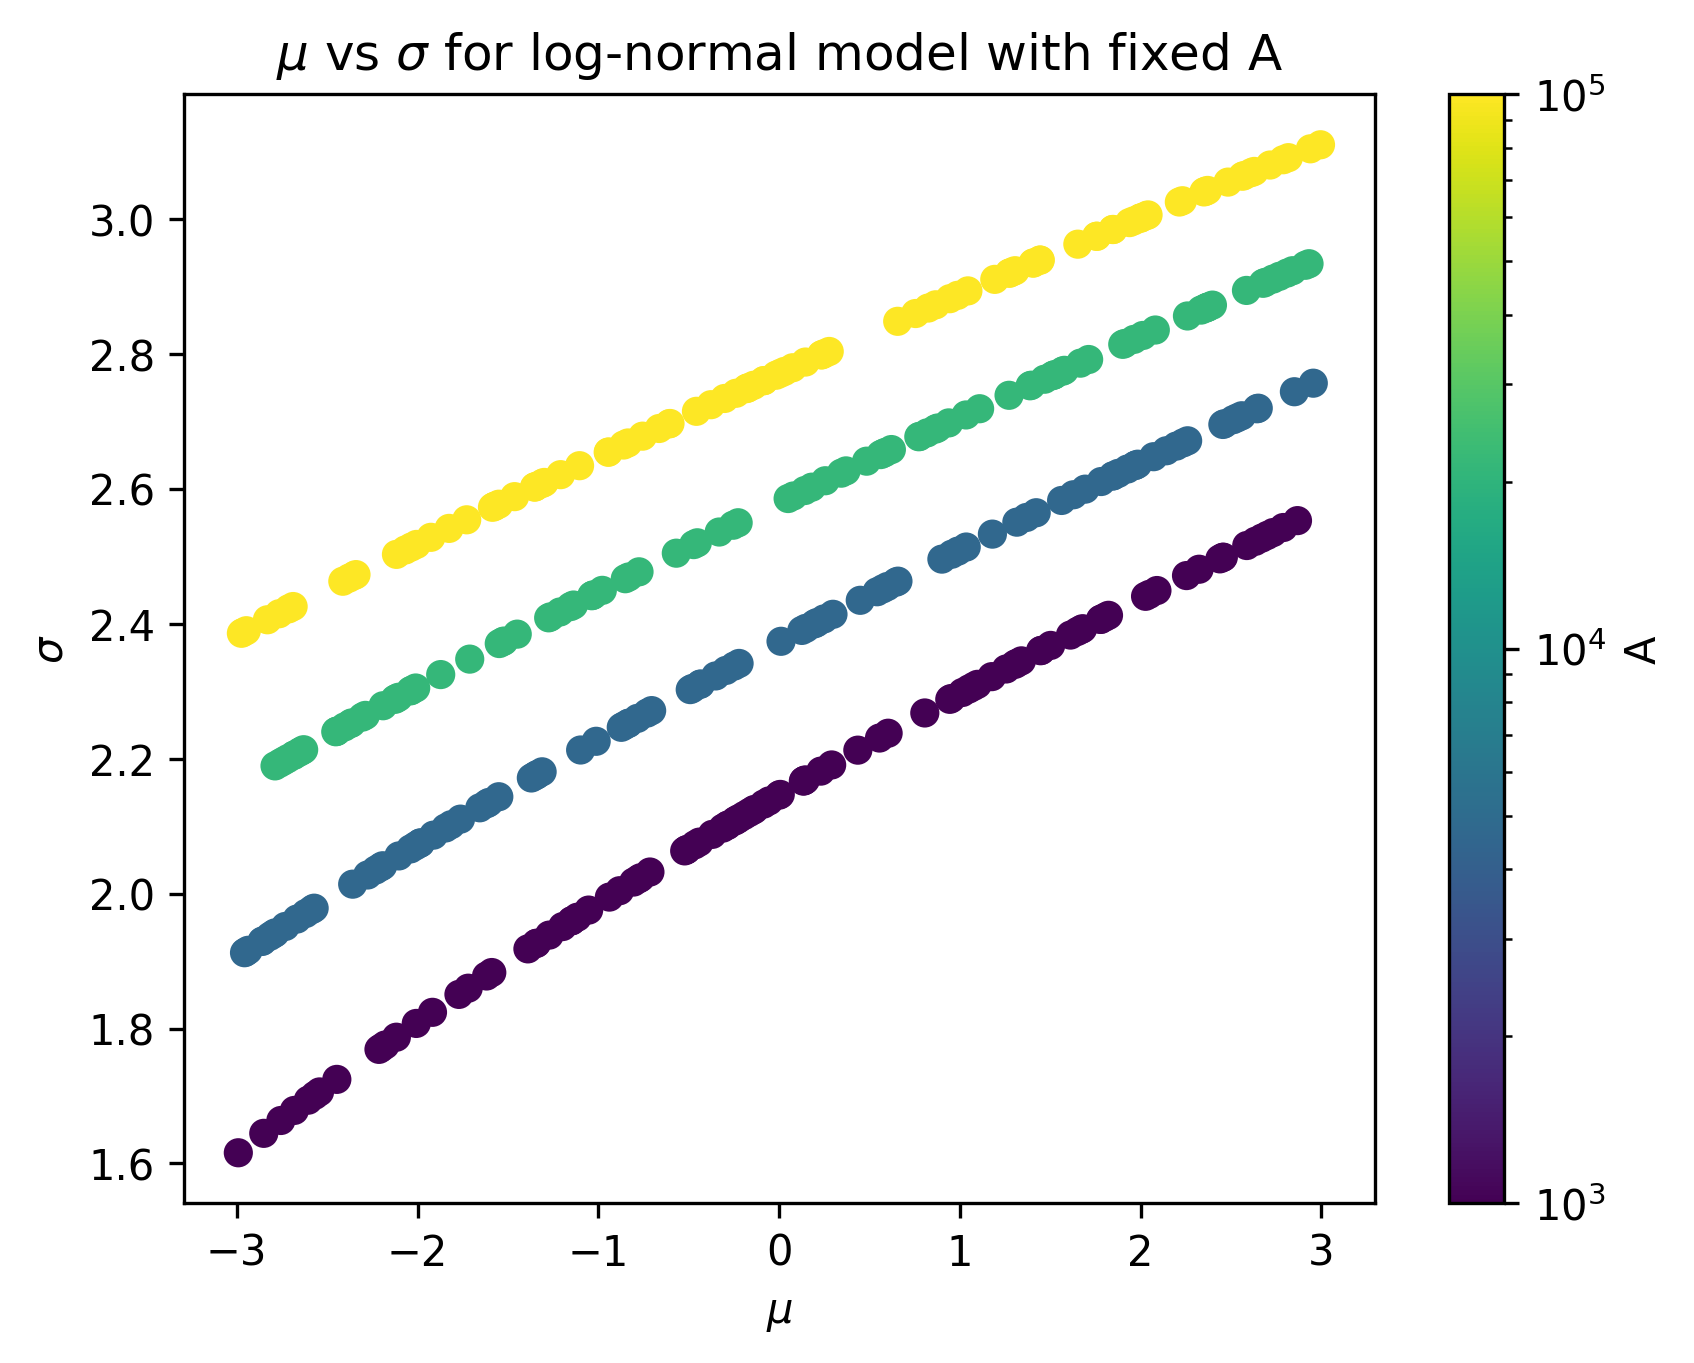

In [4]:
# In steady-state,
#   T = exp(-mu + sigma^2 / 2)
#   A = T exp(sigma^2).
# Therefore
#   sigma^2 = log(A) - log(T)
#   mu = sigma^2 / 2 - log(T)
# Combining these gives
#   mu = 3 sigma^2 / 2 - log(A)

# For fixed A, sample mu to calculate sigma
A_vals = np.logspace(3,5,num=4)
np.random.seed(7)
mus = np.random.uniform(-3, 3, size=(4, 100))
sigmas = np.sqrt(2 * (mus + np.log(A_vals[:, None])) / 3)

# Scatter coloring by A
fig, ax = plt.subplots(dpi=300)
scatter = ax.scatter(mus.flatten(), sigmas.flatten(), c=np.repeat(A_vals, 100), cmap='viridis', norm=LogNorm())
ax.set(xlabel='$\mu$', ylabel='$\sigma$', title='$\mu$ vs $\sigma$ for log-normal model with fixed A')
plt.colorbar(scatter, label='A') 



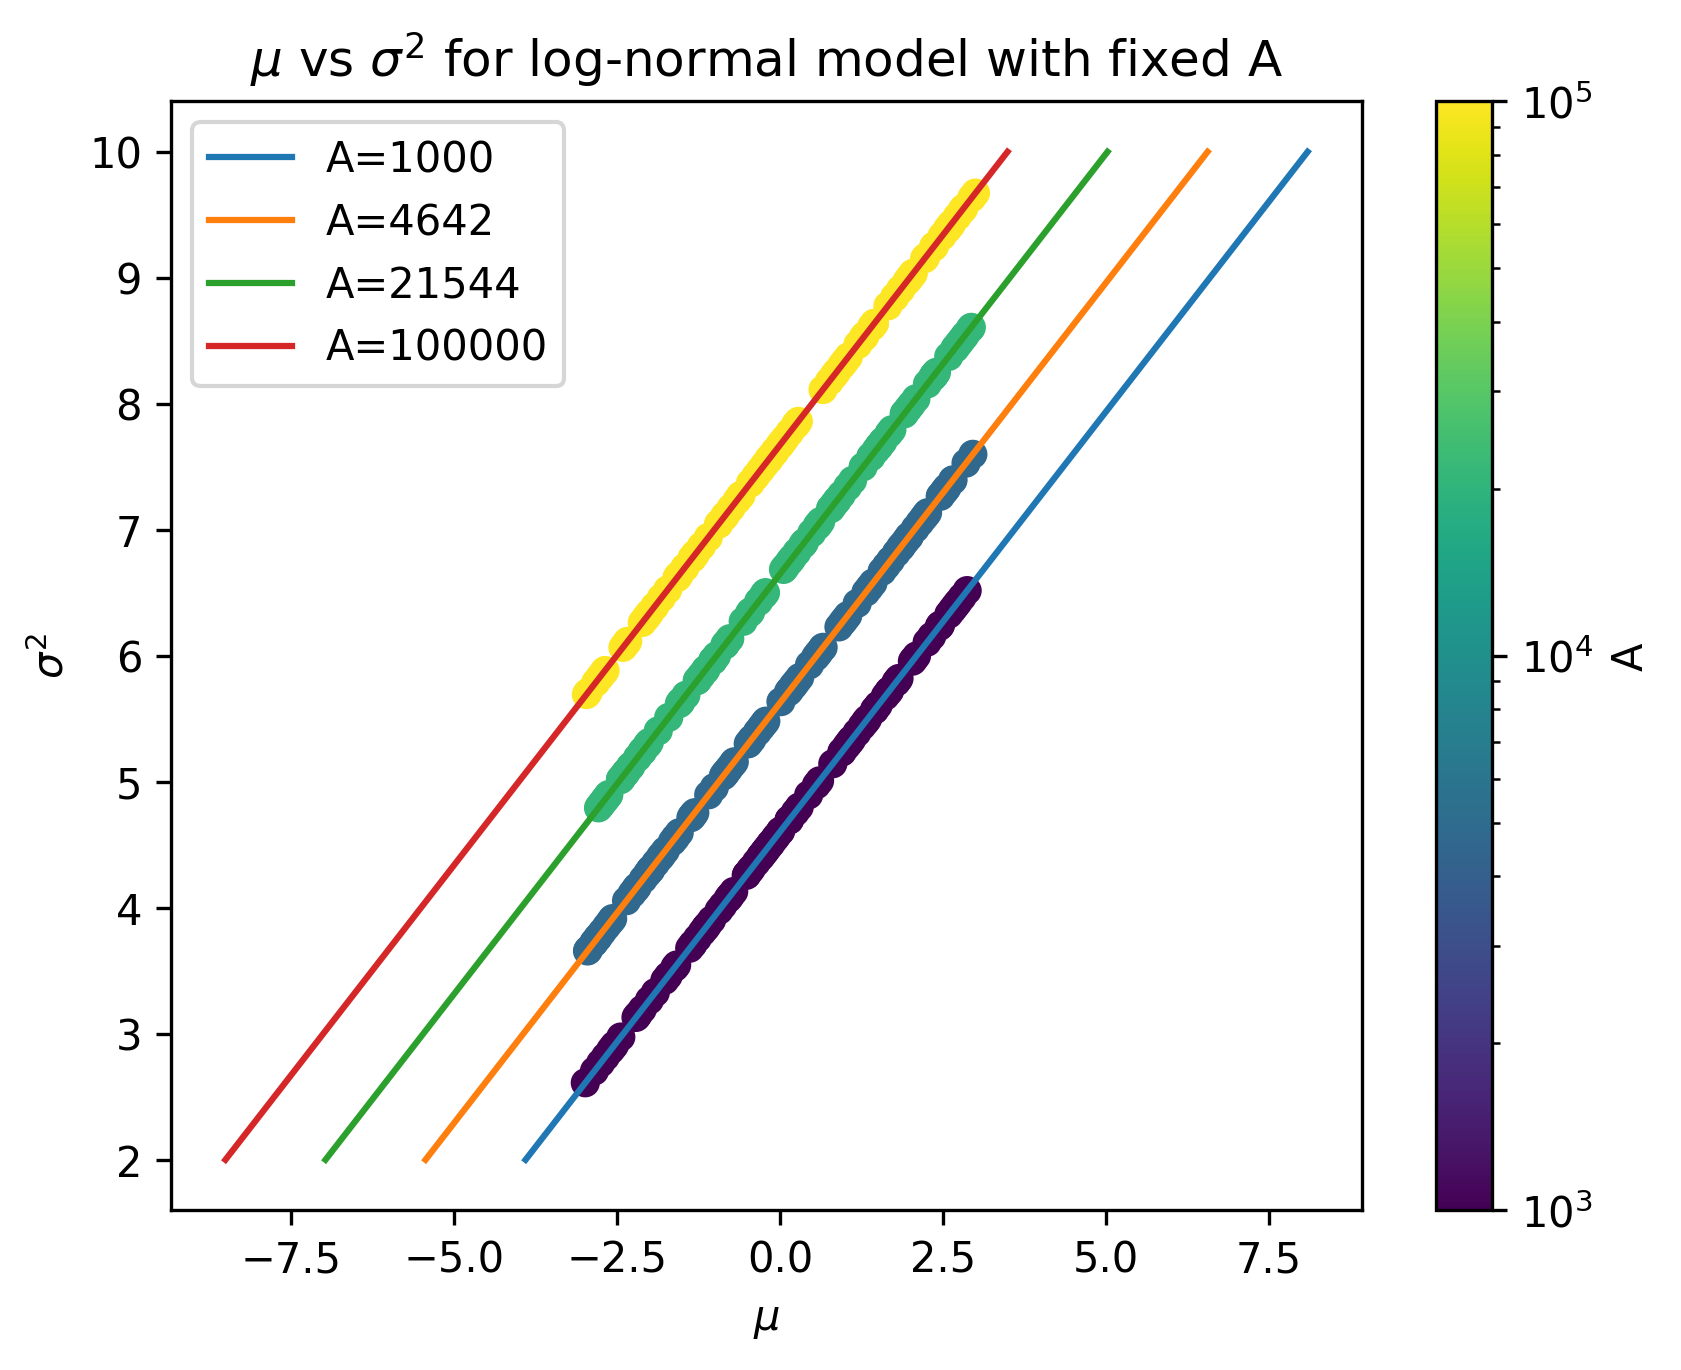

In [5]:
# Scatter mu against sigma^2, coloring by A to emphasize slope = 3/2
fig, ax = plt.subplots(dpi=300)
scatter = ax.scatter(mus.flatten(), sigmas.flatten()**2, c=np.repeat(A_vals, 100), cmap='viridis', norm=LogNorm())
ax.set(xlabel='$\mu$', ylabel='$\sigma^2$', title='$\mu$ vs $\sigma^2$ for log-normal model with fixed A')
# For each value of A, plot the line mu = 3 sigma^2 / 2 - log(A)
for A in A_vals:
    sigma2 = np.linspace(2, 10, 100)
    mu = 3 * sigma2 / 2 - np.log(A)
    ax.plot(mu, sigma2, label=f'A={A:.0f}')
ax.legend()
plt.colorbar(scatter, label='A')